# Diabetes Regression Lab

**Name: Mahesh Gaire** 

**Course: MSCS-634-M20** 

**Lab: Multiple Regression & Regularization** 

This notebook uses the Diabetes dataset from `sklearn.datasets` to explore linear, multiple, polynomial, ridge, and lasso regression models. Evaluation metrics (MAE, MSE, RMSE, R²) and visualizations are included.

In [16]:
# Section 1: Data Preparation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

# load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="progression")

# quick peek
print(X.head())
print(y.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: progression, dtype: float64


age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64


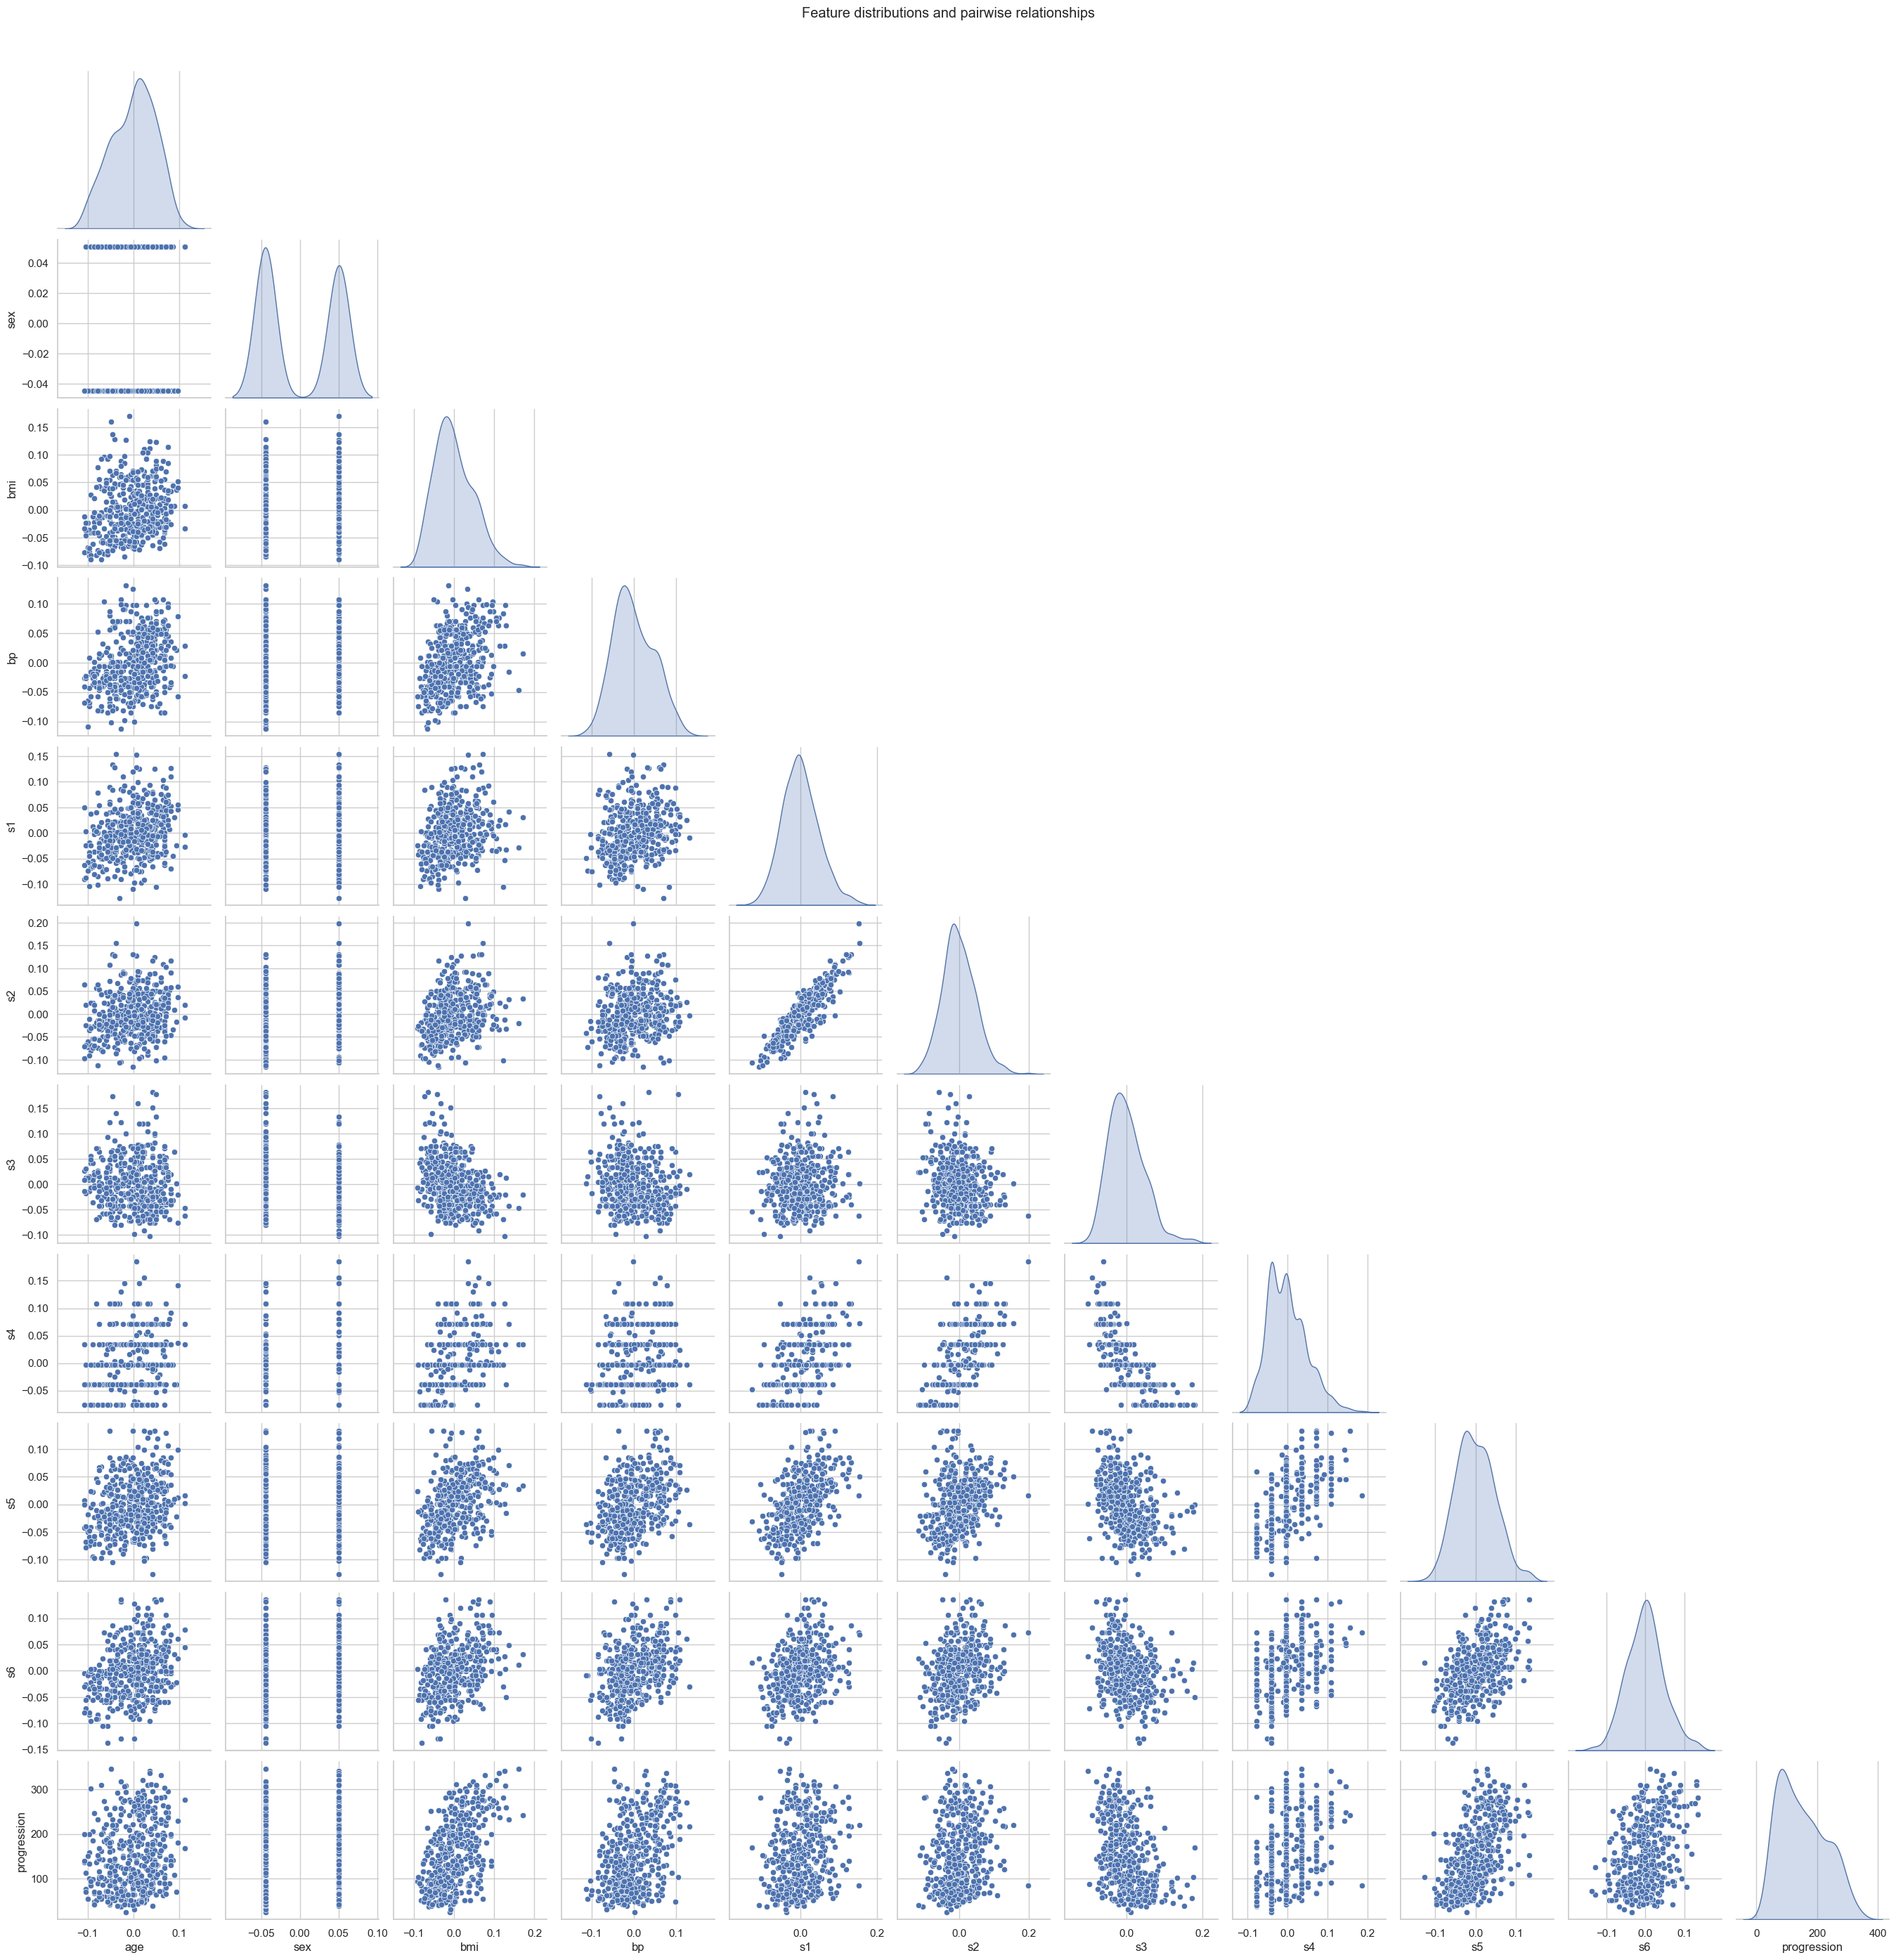

In [17]:
# check for missing values
print(X.isna().sum())

# basic distribution
sns.pairplot(pd.concat([X, y], axis=1), diag_kind="kde", corner=True)
plt.suptitle("Feature distributions and pairwise relationships", y=1.02)
plt.show()

## Dataset Overview and Cleaning

The Diabetes dataset has 442 samples with 10 baseline variables, such as age,
sex, BMI, blood pressure and various serum measurements. We checked for missing
values and found none; the DataFrame is complete, so no imputation is required.
The pairplot above shows roughly linear relationships between some features and
the disease progression target, which motivates the regression models that follow.

In [18]:
# split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


## Section 2: Linear Regression

Use a single feature (`bmi`) to predict disease progression.

Linear regression metrics (bmi): (52.25997644534553, 4061.8259284949268, np.float64(63.73245584860925), 0.23335039815872138)


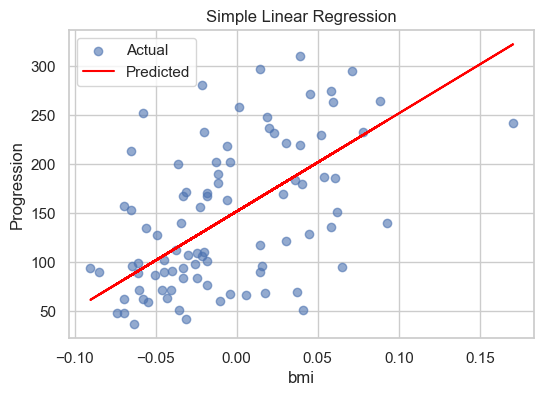

In [19]:
# choose one feature
feature = "bmi"
lin = LinearRegression()
lin.fit(X_train[[feature]], y_train)
y_pred_lin = lin.predict(X_test[[feature]])

# metrics
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

metrics_lin = regression_metrics(y_test, y_pred_lin)
print("Linear regression metrics (bmi):", metrics_lin)

# plot
plt.figure(figsize=(6,4))
plt.scatter(X_test[feature], y_test, label="Actual", alpha=0.6)
plt.plot(X_test[feature], y_pred_lin, color="red", label="Predicted")
plt.xlabel(feature)
plt.ylabel("Progression")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## Interpretation of Linear Model Results

The simple linear regression used BMI as the predictor. After training, we
computed MAE, MSE, RMSE, and R² to quantify errors and goodness-of-fit. Higher R²
values (closer to 1) indicate better fit; RMSE provides error in the original
target units. The scatter plot above shows predictions roughly tracking actual
values, but with noticeable scatter – motivating more complex models.

## Section 3: Multiple Regression

Use all features for prediction.

Multiple regression metrics: (42.79409467959994, 2900.1936284934814, np.float64(53.85344583676593), 0.4526027629719195)


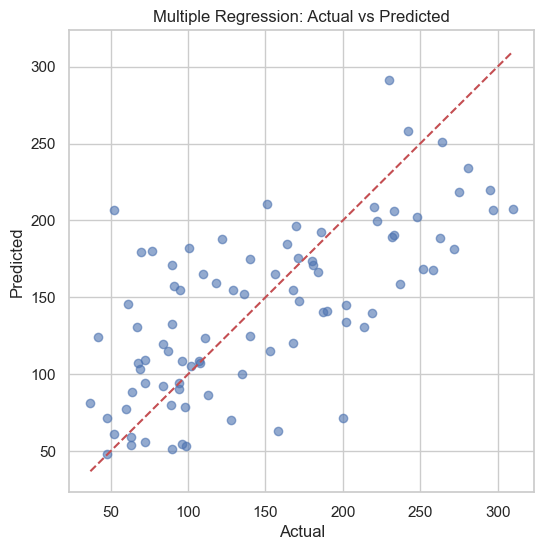

In [20]:
mult = LinearRegression()
mult.fit(X_train, y_train)
y_pred_mult = mult.predict(X_test)
metrics_mult = regression_metrics(y_test, y_pred_mult)
print("Multiple regression metrics:", metrics_mult)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mult, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression: Actual vs Predicted")
plt.show()

## Multiple Regression Insights

Using all available features improved performance metrics compared to the
single-variable model. The actual vs. predicted scatter plot should lie closer
to the dashed diagonal line when predictions are accurate. This demonstrates
that incorporating more predictors helps capture the variance in progression.
We can also inspect model coefficients later to understand feature importance.

## Section 4: Polynomial Regression

Create polynomial features and compare degrees.

Degree 2 metrics: (52.38391176015265, 4085.0254808716318, np.float64(63.914204061942534), 0.2289715971205668)
Degree 3 metrics: (52.18140033344566, 4064.443383716435, np.float64(63.752987253276494), 0.2328563664009029)
Degree 4 metrics: (52.376339291753006, 4226.144877526156, np.float64(65.0088061536755), 0.20233600732379753)


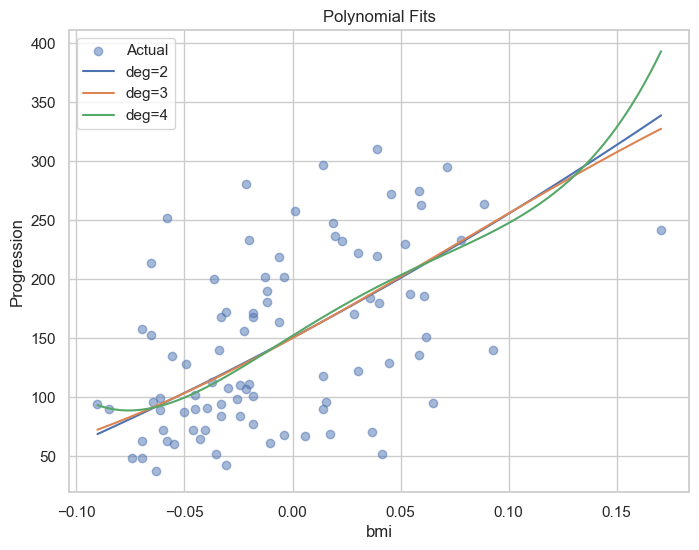

In [22]:
degrees = [2,3,4]
poly_results = {}
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train[[feature]])
    X_test_poly = poly.transform(X_test[[feature]])
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    y_pred = lr.predict(X_test_poly)
    poly_results[d] = regression_metrics(y_test, y_pred)
    print(f"Degree {d} metrics:", poly_results[d])

# plot for each
# convert grid to DataFrame to preserve feature names and avoid warnings
grid = np.linspace(X_test[feature].min(), X_test[feature].max(), 100).reshape(-1,1)
grid_df = pd.DataFrame(grid, columns=[feature])
plt.figure(figsize=(8,6))
plt.scatter(X_test[feature], y_test, alpha=0.5, label="Actual")
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    lr = LinearRegression().fit(poly.fit_transform(X_train[[feature]]), y_train)
    plt.plot(grid, lr.predict(poly.transform(grid_df)), label=f"deg={d}")
plt.xlabel(feature)
plt.ylabel("Progression")
plt.title("Polynomial Fits")

plt.legend()
plt.show()

## Polynomial Degree Effects

By fitting polynomial models of increasing degree we can observe how flexibility
impacts performance. Lower-degree polynomials may underfit, while high degrees
can overfit the training data, leading to large errors on unseen test data. The
printed metrics and the overlaid curves on the scatter plot help illustrate
these behaviors.

## Section 5: Ridge and Lasso Regularization

Train models with several alpha values.

Ridge results: {0.1: (42.996932141596524, 2856.4868876706537, np.float64(53.446111997699646), 0.46085219464119265), 1: (46.138857666974516, 3077.4159388272296, np.float64(55.47446204180109), 0.41915292635986556), 10: (58.030756410038286, 4443.952636663019, np.float64(66.66297800625935), 0.1612258675098811)}
Lasso results: {0.1: (42.85442771664998, 2798.1934851697188, np.float64(52.897953506442185), 0.4718547867276227), 1: (49.73032753662261, 3403.575721607074, np.float64(58.340172450954185), 0.3575918767219113), 10: (64.00646146990485, 5361.533457238513, np.float64(73.22249283682244), -0.011962984778542296)}


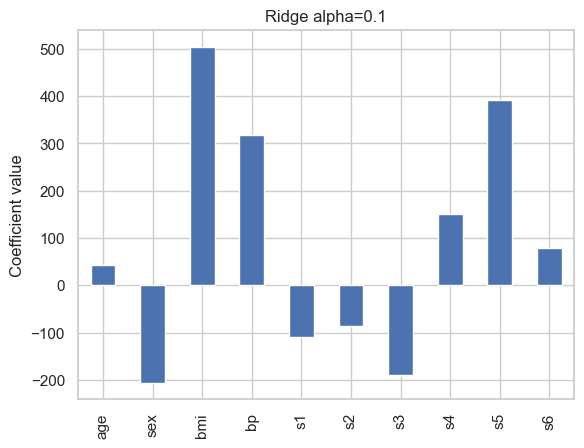

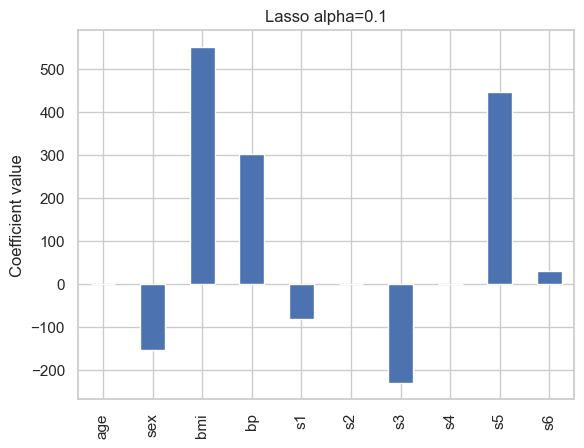

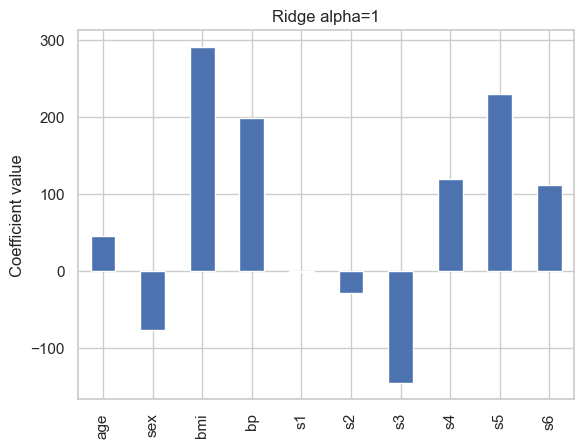

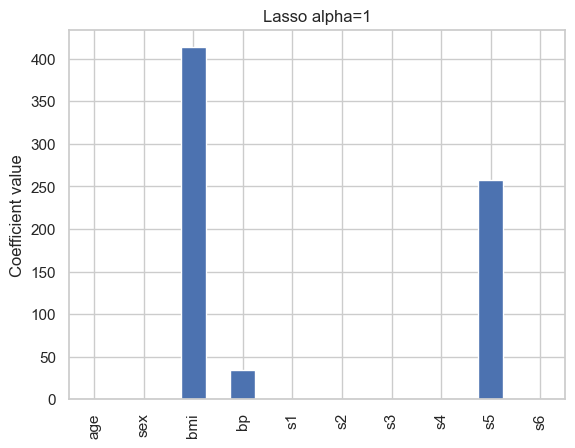

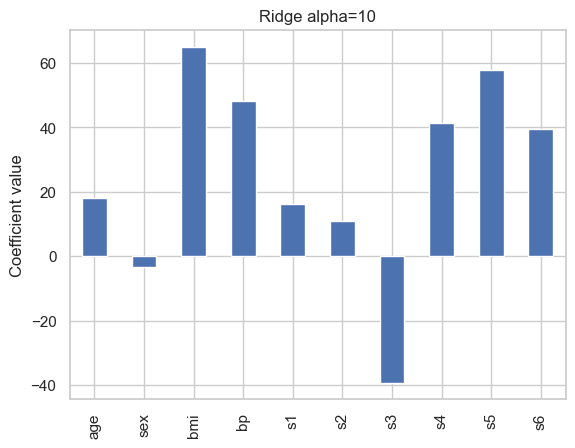

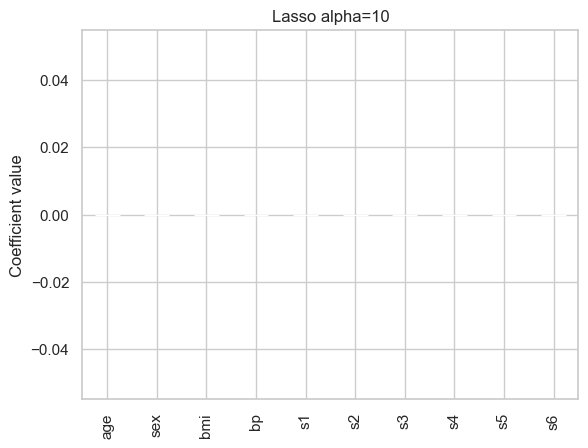

In [24]:
alphas = [0.1, 1, 10]
reg_results = {'ridge':{}, 'lasso':{}}
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_r = ridge.predict(X_test)
    reg_results['ridge'][a] = regression_metrics(y_test, y_r)
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_l = lasso.predict(X_test)
    reg_results['lasso'][a] = regression_metrics(y_test, y_l)

print("Ridge results:", reg_results['ridge'])
print("Lasso results:", reg_results['lasso'])

# visualize coefficients
def plot_coefs(model, title):
    coefs = pd.Series(model.coef_, index=X.columns)
    coefs.plot(kind='bar')
    plt.title(title)
    plt.ylabel('Coefficient value')
    plt.show()

for a in alphas:
    plot_coefs(Ridge(alpha=a).fit(X_train, y_train), f"Ridge alpha={a}")
    plot_coefs(Lasso(alpha=a).fit(X_train, y_train), f"Lasso alpha={a}")

## Understanding Regularization

Ridge and Lasso add penalties proportional to the squared and absolute
coefficients, respectively. Adjusting the `alpha` parameter controls the strength
of this penalty. Larger alphas shrink coefficients more aggressively; Lasso can
set some coefficients exactly to zero, providing feature selection. The
printed metrics and coefficient bar plots below make these effects visible.

## Section 6: Model Comparison and Analysis

Summarize performance and observations.

In [27]:
# assemble summary table
rows = []
rows.append(("Linear (bmi)",) + metrics_lin)
rows.append(("Multiple",) + metrics_mult)
for d,vals in poly_results.items():
    rows.append((f"Poly deg={d}",) + vals)
for reg in reg_results:
    for a,vals in reg_results[reg].items():
        rows.append((f"{reg.capitalize()} a={a}",) + vals)

summary_df = pd.DataFrame(rows, columns=['Model','MAE','MSE','RMSE','R2'])
summary_df

# brief textual notes
print("\nObservations:")
print("- Multiple regression improved over simple linear.")
print("- Higher-degree polynomials fit training data closely but may overfit.")
print("  Degree 4 in particular exhibited larger test error than degree 2.")
print("- Ridge and Lasso shrank coefficients; Lasso set some to zero.")
print("- Increasing alpha increased bias and reduced variance, as seen in metrics.")
print("- Regularization helped control overfitting when polynomial degree or feature")
print("  count grew.")
print("- The Diabetes dataset shows moderate linear relationships and benefits from")
print("  multiple features; however, careful tuning is needed to avoid overfitting.")
print("\nModel comparison table above summarises all approaches side-by-side.")


Observations:
- Multiple regression improved over simple linear.
- Higher-degree polynomials fit training data closely but may overfit.
  Degree 4 in particular exhibited larger test error than degree 2.
- Ridge and Lasso shrank coefficients; Lasso set some to zero.
- Increasing alpha increased bias and reduced variance, as seen in metrics.
- Regularization helped control overfitting when polynomial degree or feature
  count grew.
- The Diabetes dataset shows moderate linear relationships and benefits from
  multiple features; however, careful tuning is needed to avoid overfitting.

Model comparison table above summarises all approaches side-by-side.
